In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('car_fuel_efficiency_2026.csv')

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [5]:
df=df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


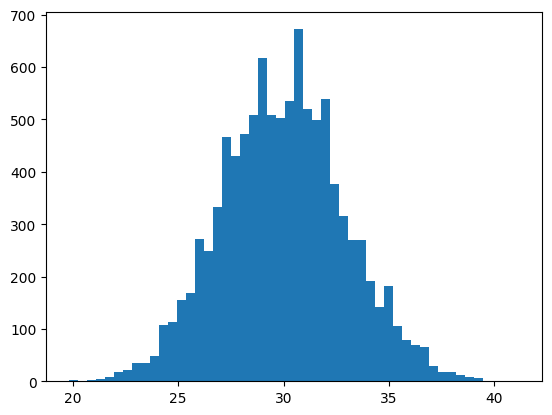

In [6]:
plt.hist(df['fuel_efficiency_mpg'],bins=50)
plt.show()

In [7]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [8]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [9]:
df['horsepower'].median()

np.float64(254.0)

In [10]:
# print(df['horsepower'].describe())
df['horsepower'].quantile(0.5)

np.float64(254.0)

In [11]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
print(n,n_train,n_val,n_test)

10000 6000 2000 2000


In [12]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [13]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

y_train=df_train.fuel_efficiency_mpg.values
y_val=df_val.fuel_efficiency_mpg.values
y_test=df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [14]:
len(df_train),len(df_val),len(df_test)

(6000, 2000, 2000)

In [15]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w=XTX_inv.dot(X.T).dot(y)
    return w[0],w[1:]

In [16]:
def rmse(y,y_pred):
    se=(y-y_pred)**2
    return np.sqrt(se.mean())

In [17]:
X_train=df_train.fillna(0).values
w0,w=train_linear_regression(X_train,y_train)
X_val=df_val.fillna(0).values
y_pred=w0+X_val.dot(w)
round(rmse(y_val,y_pred),3)

np.float64(2.205)

In [18]:
mean_hp=df_train['horsepower'].mean()
print(mean_hp)

254.46338337605272


In [19]:
X_train=df_train.fillna(mean_hp).values
w0,w=train_linear_regression(X_train,y_train)
X_val=df_val.fillna(mean_hp).values
y_pred=w0+X_val.dot(w)
round(rmse(y_val,y_pred),3)

np.float64(2.202)

In [20]:
def train_linear_regression_reg(X,y,r=0.001):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0])
    XTX_inv=np.linalg.inv(XTX)
    w=XTX_inv.dot(X.T).dot(y)
    return w[0],w[1:]

In [21]:
X_train=df_train.fillna(0).values
X_val=df_val.fillna(0).values
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0,w=train_linear_regression_reg(X_train,y_train,r=r)
    y_pred=w0+X_val.dot(w)
    print(r,round(rmse(y_val,y_pred),4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [22]:
def split(df,seed):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
    return df_train,df_val,df_test

In [23]:
scores=[]
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    tr,va,te=split(df,s)
    ytr=tr.pop('fuel_efficiency_mpg').values
    yva=va.pop('fuel_efficiency_mpg').values
    w0,w=train_linear_regression(tr.fillna(0).values,ytr)
    y_pred=w0+va.fillna(0).values.dot(w)
    scores.append(rmse(yva,y_pred))
scores

[np.float64(2.239204143046126),
 np.float64(2.2021128210838845),
 np.float64(2.1634197787530947),
 np.float64(2.2043588768539224),
 np.float64(2.2018800943311554),
 np.float64(2.2457851509085134),
 np.float64(2.2697212079524043),
 np.float64(2.190794599933443),
 np.float64(2.216611201686444),
 np.float64(2.2070365928178957)]

In [24]:
round(np.std(scores),3)

np.float64(0.029)

In [25]:
tr,va,te=split(df,9)
full=pd.concat([tr,va]).reset_index(drop=True)
y_full=full.pop('fuel_efficiency_mpg').values
y_te=te.pop('fuel_efficiency_mpg').values
# print(full.shape,te.shape)

In [26]:
w0,w=train_linear_regression_reg(full.fillna(0).values,y_full,r=0.001)
y_pred=w0+te.fillna(0).values.dot(w)
rmse(y_te,y_pred)

np.float64(2.235827747191731)